# Cartpole TrajOpt and Learning Testing Notebook

In [10]:
# Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
from jax import numpy as jp
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

# Import MuJoCo Playground
import mujoco_playground

## Cartpole Rollout Test

In [11]:
# Load the mujoco environment (can be from dm_control, robotic locomotion, or robotic manipulation)
env = mujoco_playground.registry.load('CartpoleBalance')

# Look at the configuration of the env
env_cfg = mujoco_playground.registry.get_default_config('CartpoleBalance')
env_cfg

action_repeat: 1
ctrl_dt: 0.01
episode_length: 1000
sim_dt: 0.01
vision: false
vision_config:
  enabled_geom_groups:
  - 0
  - 1
  - 2
  gpu_id: 0
  history: 3
  render_batch_size: 512
  render_height: 64
  render_width: 64
  use_rasterizer: false

In [12]:
# Let's do a simple rollout

# First, we must jit compile the reset and step functions
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

In [13]:
# Rollout a trajectory from the environment
state = jit_reset(rng=jax.random.PRNGKey(0))
rollout = [state]
actions_used = []

# Generate state from actions for each time step based on a sine wave for the action
f = 0.5
for i in range(env_cfg.episode_length):
    action = []
    for j in range(env.action_size):
        action.append(
            0.0
            #jp.sin(
            #    state.data.time * 2 * jp.pi * f + j * 2 * jp.pi / env.action_size
            #)
        )
    action = jp.array(action)
    actions_used.append(action)
    state = jit_step(state, action)
    rollout.append(state)

frames = env.render(rollout)
media.show_video(frames, fps=1.0 / env.dt)

100%|██████████| 1001/1001 [00:00<00:00, 1418.00it/s]


This browser does not support the video tag.


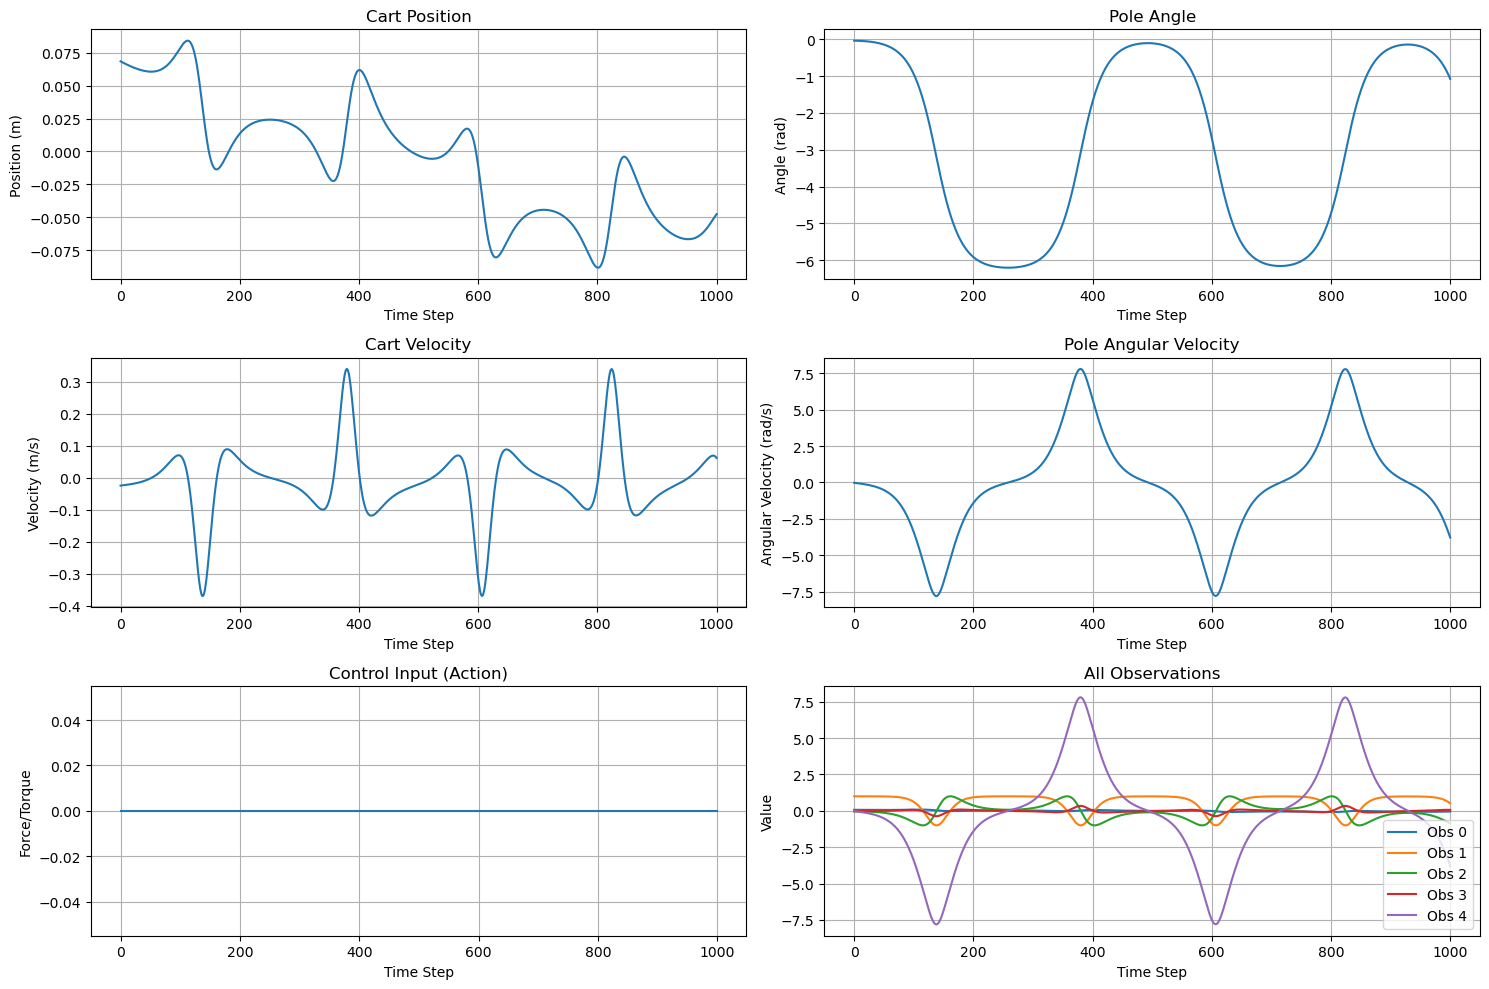

In [14]:
# Plotting

# Extract state variables for plotting
time_steps = jp.arange(len(rollout))
cart_positions = jp.array([state.data.qpos[0] for state in rollout])
pole_angles = jp.array([state.data.qpos[1] for state in rollout])  
cart_velocities = jp.array([state.data.qvel[0] for state in rollout])
pole_angular_velocities = jp.array([state.data.qvel[1] for state in rollout])

# Convert actions to array for plotting
actions_array = jp.array(actions_used)

# Create plots
plt.figure(figsize=(15, 10))

# Plot cart position
plt.subplot(3, 2, 1)
plt.plot(time_steps, cart_positions)
plt.title('Cart Position')
plt.xlabel('Time Step')
plt.ylabel('Position (m)')
plt.grid(True)

# Plot pole angle
plt.subplot(3, 2, 2)
plt.plot(time_steps, pole_angles)
plt.title('Pole Angle')
plt.xlabel('Time Step')
plt.ylabel('Angle (rad)')
plt.grid(True)

# Plot cart velocity
plt.subplot(3, 2, 3)
plt.plot(time_steps, cart_velocities)
plt.title('Cart Velocity')
plt.xlabel('Time Step')
plt.ylabel('Velocity (m/s)')
plt.grid(True)

# Plot pole angular velocity
plt.subplot(3, 2, 4)
plt.plot(time_steps, pole_angular_velocities)
plt.title('Pole Angular Velocity')
plt.xlabel('Time Step')
plt.ylabel('Angular Velocity (rad/s)')
plt.grid(True)

# Plot control input (action)
plt.subplot(3, 2, 5)
plt.plot(time_steps[:-1], actions_array.flatten())  # actions_array has one less element than rollout
plt.title('Control Input (Action)')
plt.xlabel('Time Step')
plt.ylabel('Force/Torque')
plt.grid(True)

# Plot all observations together
plt.subplot(3, 2, 6)
observations = jp.array([state.obs for state in rollout])
for i in range(observations.shape[1]):
    plt.plot(time_steps, observations[:, i], label=f'Obs {i}')
plt.title('All Observations')
plt.xlabel('Time Step')
plt.ylabel('Value')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Notice how the env runs and lives on the device (GPU), this enables large-batch RL
state.obs.device

# Also make sure the default backend is the GPU and not CPU
print(jax.default_backend())

gpu


## Extracting the Dynamics (Equations of Motion) From MuJoCo
Here we try to figure out how to get the equations of motion from the mujoco model to use them as the dynamics function. This is since the available JAX trajopt iLQR solvers need explicitly written dynamics to differentiate.

In [16]:
# Simple access to MuJoCo model and data
mj_model = env.mj_model  # CPU-based MuJoCo model
mjx_model = env.mjx_model  # GPU-based MJX model

# Get current state and its MJX data
current_state = rollout[0]
mjx_data = current_state.data  # This is MJX data (GPU-based)

# To get traditional CPU-based MjData, create it from the model
mj_data = mujoco.MjData(mj_model)
mj_data.qpos[:] = mjx_data.qpos
mj_data.qvel[:] = mjx_data.qvel
mujoco.mj_forward(mj_model, mj_data)  # Update dependent quantities

print(f"MjModel: {type(mj_model)}")
print(f"MjData: {type(mj_data)}")
print(f"MJX Data: {type(mjx_data)}")

# Access key data
print(f"Current qpos: {mj_data.qpos}")
print(f"Current qvel: {mj_data.qvel}")
print(f"Center of mass: {mj_data.subtree_com[1]}")  # Cart body

MjModel: <class 'mujoco._structs.MjModel'>
MjData: <class 'mujoco._structs.MjData'>
MJX Data: <class 'mujoco.mjx._src.types.Data'>
Current qpos: [ 0.06846283 -0.03350402]
Current qvel: [-0.02442456 -0.02035681]
Center of mass: [0.0669402  0.         1.04542904]


Comparing custom custom integration vs MuJoCo integrator...


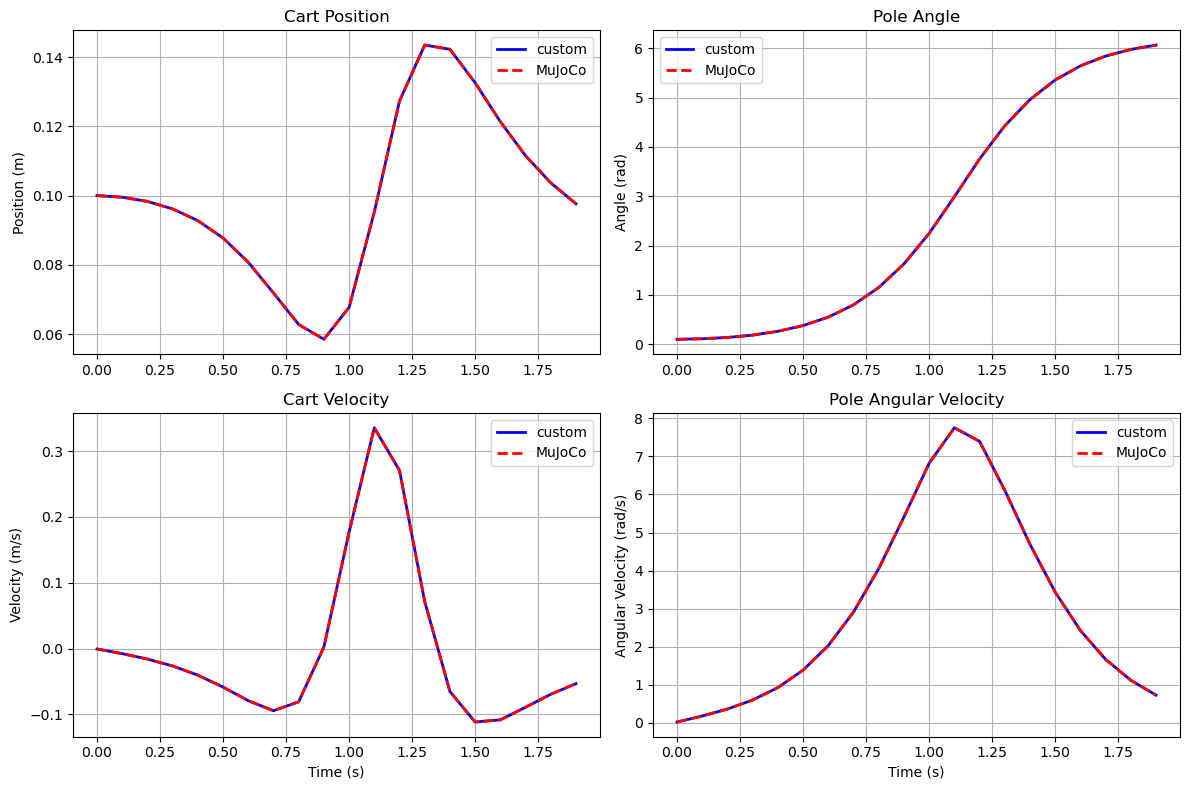


Final state comparison:
Cart position error: 0.000019 m
Pole angle error: 0.000399 rad (0.023°)
Cart velocity error: 0.000067 m/s
Pole velocity error: 0.001437 rad/s

Max errors over simulation:
Max cart position error: 0.000019 m
Max pole angle error: 0.000399 rad (0.023°)

Mass matrix at final time:
M = 
[[1.1        0.0487491 ]
 [0.0487491  0.03442459]]
Mass matrix is symmetric
Mass matrix is positive definite


In [21]:
# Extract dynamics components and implement custom integration
from scipy.linalg import solve

def get_dynamics_components(model, data):
    """Extract mass matrix M and bias forces C from MuJoCo"""
    nv = model.nv
    
    # Mass matrix M (nv x nv)
    M = np.zeros((nv, nv))
    mujoco.mj_fullM(model, M, data.qM)
    
    # Bias forces (Coriolis + gravity + other forces)
    C = data.qfrc_bias.copy()
    
    return M, C

def get_acceleration(model, data, ctrl):
    """Compute acceleration given current state and control"""
    # Set control input
    data.ctrl[:] = ctrl
    
    # Compute all forces and kinematics (this updates qfrc_bias, qM, etc.)
    mujoco.mj_forward(model, data)
    
    # Get dynamics components: M*qacc = tau - C
    M, C = get_dynamics_components(model, data)
    
    # Total applied forces (actuator forces are already included in forward pass)
    tau = data.qfrc_applied + data.qfrc_actuator
    
    # Solve for acceleration: M*qacc = tau - C
    qacc = solve(M, tau - C)
    
    return qacc

def custom_step(model, data, ctrl, dt, integrator_type="euler"):
    """custom integration step, could be either RK4 or Euler"""

    if integrator_type=="RK4":
        """RK4 integration step using extracted dynamics"""
        # Store original state
        qpos_orig = data.qpos.copy()
        qvel_orig = data.qvel.copy()
        
        # k1: derivatives at current state
        qacc_k1 = get_acceleration(model, data, ctrl)
        qvel_k1 = data.qvel.copy()
        
        # k2: derivatives at midpoint using k1
        qpos_k2 = qpos_orig.copy()
        mujoco.mj_integratePos(model, qpos_k2, qvel_k1, dt/2)
        qvel_k2 = qvel_orig + dt/2 * qacc_k1
        
        data.qpos[:] = qpos_k2
        data.qvel[:] = qvel_k2
        qacc_k2 = get_acceleration(model, data, ctrl)
        
        # k3: derivatives at midpoint using k2
        qpos_k3 = qpos_orig.copy()
        mujoco.mj_integratePos(model, qpos_k3, qvel_k2, dt/2)
        qvel_k3 = qvel_orig + dt/2 * qacc_k2
        
        data.qpos[:] = qpos_k3
        data.qvel[:] = qvel_k3
        qacc_k3 = get_acceleration(model, data, ctrl)
        
        # k4: derivatives at endpoint using k3
        qpos_k4 = qpos_orig.copy()
        mujoco.mj_integratePos(model, qpos_k4, qvel_k3, dt)
        qvel_k4 = qvel_orig + dt * qacc_k3
        
        data.qpos[:] = qpos_k4
        data.qvel[:] = qvel_k4
        qacc_k4 = get_acceleration(model, data, ctrl)
        
        # Combine using RK4 weights
        qvel_new = qvel_orig + dt/6 * (qacc_k1 + 2*qacc_k2 + 2*qacc_k3 + qacc_k4)
        qvel_avg = (qvel_k1 + 2*qvel_k2 + 2*qvel_k3 + qvel_k4) / 6
        
        # Final position integration
        qpos_new = qpos_orig.copy()
        mujoco.mj_integratePos(model, qpos_new, qvel_avg, dt)
        
        # Update state
        data.qpos[:] = qpos_new
        data.qvel[:] = qvel_new
        
        return qacc_k1  # Return initial acceleration for compatibility
    else:
        # Euler integration using extracted dynamics
        # Store original state
        qpos_orig = data.qpos.copy()
        qvel_orig = data.qvel.copy()
        
        # Compute acceleration at current state using mass matrix equations
        qacc = get_acceleration(model, data, ctrl)
        
        # Euler integration: v_new = v_old + dt * qacc
        qvel_new = qvel_orig + dt * qacc
        
        # Position integration using MuJoCo's method
        qpos_new = qpos_orig.copy()
        mujoco.mj_integratePos(model, qpos_new, qvel_new, dt)
        
        # Update state
        data.qpos[:] = qpos_new
        data.qvel[:] = qvel_new
        
        return qacc

def simulate_custom_vs_mujoco(model, duration=2.0, dt=0.01):
    """Compare custom integration vs MuJoCo's integrator"""
    steps = int(duration / dt)
    
    # Initialize two identical states
    data_custom = mujoco.MjData(model)
    data_mujoco = mujoco.MjData(model)
    
    # Set initial state (small perturbation from equilibrium)
    initial_qpos = np.array([0.1, 0.1])  # cart position, pole angle
    initial_qvel = np.array([0.0, 0.0])  # zero velocity
    
    data_custom.qpos[:] = initial_qpos
    data_custom.qvel[:] = initial_qvel
    data_mujoco.qpos[:] = initial_qpos
    data_mujoco.qvel[:] = initial_qvel
    
    # Control function (simple PD control on cart to stabilize pole)
    def get_control(qpos, qvel, t):
        cart_pos, pole_angle = qpos
        cart_vel, pole_vel = qvel
        
        # PD control to keep cart at origin and pole upright
        # NOTE: Not using just to test
        kp_cart, kd_cart = 10.0, 5.0
        kp_pole, kd_pole = 50.0, 10.0
        
        cart_force = 0.0 #-kp_cart * cart_pos - kd_cart * cart_vel
        pole_torque = 0.0 #-kp_pole * pole_angle - kd_pole * pole_vel
        
        # For cartpole, only cart force is controlled
        return np.array([cart_force + 0.5 * pole_torque])  # coupling term
    
    # Storage
    times = []
    custom_states = []
    mujoco_states = []
    mass_matrices = []
    
    # Simulate
    for step in range(steps):
        t = step * dt
        
        # Get control input
        ctrl = get_control(data_custom.qpos, data_custom.qvel, t)
        
        # Custom RK4 integration step
        qacc_custom = custom_step(model, data_custom, ctrl, dt)
        
        # MuJoCo integration step
        data_mujoco.ctrl[:] = ctrl
        mujoco.mj_step(model, data_mujoco)
        
        # Store results every 10 steps to save memory
        if step % 10 == 0:
            times.append(t)
            custom_states.append([data_custom.qpos.copy(), data_custom.qvel.copy()])
            mujoco_states.append([data_mujoco.qpos.copy(), data_mujoco.qvel.copy()])
            
            # Store mass matrix for analysis
            M, C = get_dynamics_components(model, data_custom)
            mass_matrices.append(M.copy())
    
    return times, custom_states, mujoco_states, mass_matrices

# Run the comparison
print("Comparing custom custom integration vs MuJoCo integrator...")
times, custom_states, mujoco_states, mass_matrices = simulate_custom_vs_mujoco(mj_model)

# Analyze results
custom_pos = np.array([[s[0][0], s[0][1]] for s in custom_states])  # cart_pos, pole_angle
mujoco_pos = np.array([[s[0][0], s[0][1]] for s in mujoco_states])
custom_vel = np.array([[s[1][0], s[1][1]] for s in custom_states])  # cart_vel, pole_vel  
mujoco_vel = np.array([[s[1][0], s[1][1]] for s in mujoco_states])

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Cart position
axes[0,0].plot(times, custom_pos[:,0], 'b-', label='custom', linewidth=2)
axes[0,0].plot(times, mujoco_pos[:,0], 'r--', label='MuJoCo', linewidth=2)
axes[0,0].set_title('Cart Position')
axes[0,0].set_ylabel('Position (m)')
axes[0,0].legend()
axes[0,0].grid(True)

# Pole angle
axes[0,1].plot(times, custom_pos[:,1], 'b-', label='custom', linewidth=2)
axes[0,1].plot(times, mujoco_pos[:,1], 'r--', label='MuJoCo', linewidth=2)
axes[0,1].set_title('Pole Angle')
axes[0,1].set_ylabel('Angle (rad)')
axes[0,1].legend()
axes[0,1].grid(True)

# Cart velocity
axes[1,0].plot(times, custom_vel[:,0], 'b-', label='custom', linewidth=2)
axes[1,0].plot(times, mujoco_vel[:,0], 'r--', label='MuJoCo', linewidth=2)
axes[1,0].set_title('Cart Velocity')
axes[1,0].set_xlabel('Time (s)')
axes[1,0].set_ylabel('Velocity (m/s)')
axes[1,0].legend()
axes[1,0].grid(True)

# Pole velocity
axes[1,1].plot(times, custom_vel[:,1], 'b-', label='custom', linewidth=2)
axes[1,1].plot(times, mujoco_vel[:,1], 'r--', label='MuJoCo', linewidth=2)
axes[1,1].set_title('Pole Angular Velocity')
axes[1,1].set_xlabel('Time (s)')
axes[1,1].set_ylabel('Angular Velocity (rad/s)')
axes[1,1].legend()
axes[1,1].grid(True)

plt.tight_layout()
plt.show()

# Print numerical comparison
pos_error = np.abs(custom_pos - mujoco_pos)
vel_error = np.abs(custom_vel - mujoco_vel)

print(f"\nFinal state comparison:")
print(f"Cart position error: {pos_error[-1,0]:.6f} m")
print(f"Pole angle error: {pos_error[-1,1]:.6f} rad ({pos_error[-1,1]*180/np.pi:.3f}°)")
print(f"Cart velocity error: {vel_error[-1,0]:.6f} m/s")
print(f"Pole velocity error: {vel_error[-1,1]:.6f} rad/s")

print(f"\nMax errors over simulation:")
print(f"Max cart position error: {np.max(pos_error[:,0]):.6f} m") 
print(f"Max pole angle error: {np.max(pos_error[:,1]):.6f} rad ({np.max(pos_error[:,1])*180/np.pi:.3f}°)")

# Show mass matrix structure
print(f"\nMass matrix at final time:")
M_final = mass_matrices[-1]
print(f"M = \n{M_final}")
print(f"Mass matrix is {'symmetric' if np.allclose(M_final, M_final.T) else 'not symmetric'}")
print(f"Mass matrix is {'positive definite' if np.all(np.linalg.eigvals(M_final) > 0) else 'not positive definite'}")


## Trajopt with Cartpole Environment
Here we try out a few trajectory optimization libraries written in JAX.

### trajax

In [30]:
import trajax
import jax.numpy as jnp

def cartpole_cost(x, u, t):
    """Cost function for cartpole balancing task."""
    # State: [cart_pos, pole_angle, cart_vel, pole_angular_vel] (using qpos, qvel directly)
    cart_pos = x[0]
    pole_angle = x[1]
    cart_vel = x[2]
    pole_vel = x[3]
    
    # For balance task: penalize deviation from upright (angle=0) and centered cart
    pos_cost = 10.0 * cart_pos**2
    angle_cost = 50.0 * pole_angle**2  # Penalty for deviation from upright
    vel_cost = 1.0 * (cart_vel**2 + pole_vel**2)
    control_cost = 0.01 * u[0]**2
    
    return pos_cost + angle_cost + vel_cost + control_cost


def get_mass_matrix(q):
    """Get mass matrix M as a function of configuration q = [cart_pos, pole_angle]"""
    # Create temporary MjData to compute mass matrix at configuration q
    temp_data = mujoco.MjData(env.mj_model)
    temp_data.qpos[:] = q
    mujoco.mj_forward(env.mj_model, temp_data)
    
    # Extract mass matrix
    nv = env.mj_model.nv
    M = jnp.zeros((nv, nv))
    M_np = np.zeros((nv, nv))
    mujoco.mj_fullM(env.mj_model, M_np, temp_data.qM)
    M = jnp.array(M_np)
    
    return M

def get_bias_forces(q, qvel):
    """Get bias forces C(q, qvel) = Coriolis + gravity + other forces"""
    # Create temporary MjData to compute bias forces at state (q, qvel)
    temp_data = mujoco.MjData(env.mj_model)
    temp_data.qpos[:] = q
    temp_data.qvel[:] = qvel
    mujoco.mj_forward(env.mj_model, temp_data)
    
    # Extract bias forces
    C = jnp.array(temp_data.qfrc_bias)
    
    return C

def cartpole_dynamics(x, u, t):
    """Cartpole dynamics using the equations of motion derived from MuJoCo.
    
    Args:
        x: State vector [cart_pos, pole_angle, cart_vel, pole_angular_vel]
        u: Control vector [cart_force]
        t: Time (unused)
    
    Returns:
        State derivative [cart_vel, pole_angular_vel, cart_acc, pole_angular_acc]
    """
    # Split state into positions and velocities
    nv = env.mj_model.nv  # Should be 2 for cartpole (cart + pole)
    q, qvel = jnp.split(x, [nv])  # q = [cart_pos, pole_angle], qvel = [cart_vel, pole_vel]
    
    # Get mass matrix M(q) and bias forces C(q, qvel)
    M = get_mass_matrix(q)
    C = get_bias_forces(q, qvel)
    
    # Applied forces tau (control input affects the cart)
    # For cartpole, control force affects cart DOF
    tau = jnp.array([u[0], 0.0])  # [cart_force, pole_torque=0]
    
    # Solve equations of motion: M(q) * qddot = tau - C(q, qvel)
    # qddot = M^{-1} * (tau - C)
    qddot = jnp.linalg.solve(M, tau - C)
    
    # Return state derivative [qvel, qddot]
    return jnp.concatenate([qvel, qddot])

dynamics = trajax.integrators.euler(cartpole_dynamics, dt=env.dt)

### lqrax

In [ ]:
import lqrax
from lqrax import iLQR

# Define a CartpoleILQR class that extends LQRax's iLQR as in the example notebooks
class CartpoleILQR(iLQR):
    def __init__(self, dt, x_dim, u_dim, Q, R):
        super().__init__(dt, x_dim, u_dim, Q, R)
        # Store jit functions for use in dynamics
        self.jit_reset = jax.jit(env.reset)
        self.jit_step = jax.jit(env.step)
    
    def dyn(self, xt, ut):
        """Cartpole dynamics using the equations of motion derived from mujoco."""

        # TODO: This current thing is obviously incorrect as there's no equations of motion here.

        # Create a dummy state with the current observation
        dummy_state = self.jit_reset(rng=jax.random.PRNGKey(0))
        current_state = dummy_state.replace(obs=xt)
        
        # Step the environment with the control input
        next_state = self.jit_step(current_state, ut)
        
        # Return the next observation
        return next_state.obs

# Setup Q and R matrices for cartpole balancing
Q = jp.diag(jp.array([10.0, 50.0, 50.0, 1.0, 1.0]))  # [cart_pos, cos_pole, sin_pole, cart_vel, pole_vel]
R = jp.array([[0.01]])  # control cost

# Create the CartpoleILQR instance
cartpole_ilqr = CartpoleILQR(dt=env.dt, x_dim=5, u_dim=1, Q=Q, R=R)

# Test the dynamics function
print("Testing LQRax dynamics function...")
x_test = jp.array([0.1, 0.95, 0.31, 0.0, 0.0])
u_test = jp.array([1.0])
x_next = cartpole_ilqr.dyn(x_test, u_test)
print(f"Initial state: {x_test}")
print(f"Next state: {x_next}")

# Setup trajectory optimization
T = 100
x0 = jp.array([0.1, 0.95, 0.31, 0.0, 0.0])  # slightly off-balance starting position

# Initialize control trajectory with small random values
rng = jax.random.PRNGKey(42)
u_traj = jax.random.normal(rng, (T, 1)) * 0.1

# Define loss function components
def cartpole_loss(x_traj, u_traj):
    """Total loss for cartpole balancing."""
    # State cost: penalize deviation from upright (cos=1, sin=0) and centered cart
    pos_cost = 10.0 * jp.sum(x_traj[:, 0]**2)  # cart position
    angle_cost = 50.0 * jp.sum((x_traj[:, 1] - 1.0)**2 + x_traj[:, 2]**2)  # cos/sin pole angle
    vel_cost = 1.0 * jp.sum(x_traj[:, 3]**2 + x_traj[:, 4]**2)  # velocities
    control_cost = 0.01 * jp.sum(u_traj**2)  # control effort
    
    return pos_cost + angle_cost + vel_cost + control_cost

# Define linearization functions for the loss
@jax.jit
def linearize_loss(x_traj, u_traj):
    """Linearize the loss function to get a_traj and b_traj."""
    # For LQRax iLQR, we need gradients of loss w.r.t. state and control at each time step
    def loss_at_t(xt, ut):
        pos_cost = 10.0 * xt[0]**2
        angle_cost = 50.0 * ((xt[1] - 1.0)**2 + xt[2]**2) 
        vel_cost = 1.0 * (xt[3]**2 + xt[4]**2)
        control_cost = 0.01 * ut[0]**2
        return pos_cost + angle_cost + vel_cost + control_cost
    
    # Compute gradients
    dldx = jax.grad(loss_at_t, argnums=0)
    dldu = jax.grad(loss_at_t, argnums=1)
    
    # Apply to all time steps
    a_traj = jax.vmap(dldx, in_axes=(0, 0))(x_traj, u_traj)
    b_traj = jax.vmap(dldu, in_axes=(0, 0))(x_traj, u_traj)
    
    return a_traj, b_traj

# iLQR optimization loop
num_iters = 20
print(f"\nRunning LQRax iLQR optimization for {num_iters} iterations...")

for iteration in range(num_iters):
    # Linearize dynamics around current trajectory
    x_traj, A_traj, B_traj = cartpole_ilqr.linearize_dyn(x0, u_traj)
    
    # Linearize loss function
    a_traj, b_traj = linearize_loss(x_traj, u_traj)
    
    # Solve iLQR subproblem to get descent direction
    v_traj, z_traj = cartpole_ilqr.solve(A_traj, B_traj, a_traj, b_traj)
    
    # Line search for step size
    step_sizes = jp.array([0.001, 0.01, 0.1, 0.5, 1.0])
    best_loss = jp.inf
    best_step = 0.0
    
    for step in step_sizes:
        u_new = u_traj + step * v_traj
        x_new = cartpole_ilqr.traj_sim(x0, u_new)
        loss_val = cartpole_loss(x_new, u_new)
        if loss_val < best_loss:
            best_loss = loss_val
            best_step = step
    
    # Update control trajectory
    u_traj = u_traj + best_step * v_traj
    
    # Print progress
    if iteration % 5 == 0 or iteration == num_iters - 1:
        final_x_traj = cartpole_ilqr.traj_sim(x0, u_traj)
        loss_val = cartpole_loss(final_x_traj, u_traj)
        print(f"Iteration {iteration:2d}: loss = {loss_val:.4f}, step_size = {best_step:.3f}")

# Final results
print("\nOptimization complete!")
final_x_traj = cartpole_ilqr.traj_sim(x0, u_traj)
final_loss = cartpole_loss(final_x_traj, u_traj)

print(f"Final loss: {final_loss:.4f}")
print(f"Control variation - min: {jp.min(u_traj):.6f}, max: {jp.max(u_traj):.6f}, std: {jp.std(u_traj):.6f}")

# Convert cos/sin back to angle for summary
pole_angles = jp.arctan2(final_x_traj[:, 2], final_x_traj[:, 1])
print(f"Initial pole angle: {pole_angles[0] * 180/jp.pi:.1f}°")
print(f"Final pole angle: {pole_angles[-1] * 180/jp.pi:.1f}°")
print(f"Max cart displacement: {jp.max(jp.abs(final_x_traj[:, 0])):.3f}m")

# Create and render rollout from optimized trajectory
print("\nCreating optimized cartpole rollout...")
rollout_state = jit_reset(rng=jax.random.PRNGKey(0))
rollout_state = rollout_state.replace(obs=x0)
opt_rollout = [rollout_state]

for i in range(T):
    action = jp.array([u_traj[i, 0]])
    rollout_state = jit_step(rollout_state, action)
    opt_rollout.append(rollout_state)

print("Rendering optimized trajectory...")
frames = env.render(opt_rollout)
media.show_video(frames, fps=1.0 / env.dt)

Testing LQRax dynamics function...
Initial state: [0.1  0.95 0.31 0.   0.  ]
Next state: [ 0.06919418  0.99943876 -0.03349775  0.07313518 -0.16675085]

Running LQRax iLQR optimization for 20 iterations...
Iteration  0: loss = 1898.4506, step_size = 0.500
Iteration  5: loss = 1898.4504, step_size = 0.001
Iteration 10: loss = 1898.4504, step_size = 0.001
Iteration 15: loss = 1898.4504, step_size = 0.001
Iteration 19: loss = 1898.4504, step_size = 0.001

Optimization complete!
Final loss: 1898.4504
Control variation - min: -0.095411, max: -0.001368, std: 0.026272
Initial pole angle: 17.9°
Final pole angle: 8.1°
Max cart displacement: 0.168m

Creating optimized cartpole rollout...
Rendering optimized trajectory...


100%|██████████| 101/101 [00:00<00:00, 1515.13it/s]


This browser does not support the video tag.


## RL with Cartpole Environment

Here we compare the Brax implementations and SBX implementations

### Brax

In [ ]:
from mujoco_playground.config import dm_control_suite_params
ppo_params = dm_control_suite_params.brax_ppo_config('CartpoleBalance')
sac_params = dm_control_suite_params.brax_sac_config('CartpoleBalance')
ppo_params

action_repeat: 1
batch_size: 1024
discounting: 0.995
entropy_cost: 0.01
episode_length: 1000
learning_rate: 0.001
normalize_observations: true
num_envs: 2048
num_evals: 10
num_minibatches: 32
num_timesteps: 60000000
num_updates_per_batch: 16
reward_scaling: 10.0
unroll_length: 30

#### Brax PPO

In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, ppo_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

ppo_training_params = dict(ppo_params)
network_factory = ppo_networks.make_ppo_networks
if "network_factory" in ppo_params:
  del ppo_training_params["network_factory"]
  network_factory = functools.partial(
      ppo_networks.make_ppo_networks,
      **ppo_params.network_factory
  )

train_fn = functools.partial(
    ppo.train, **dict(ppo_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

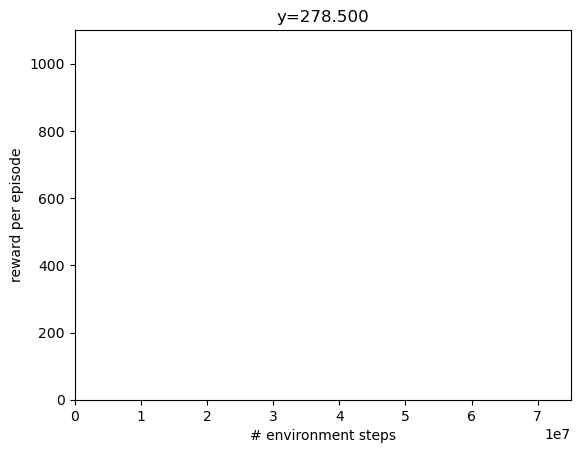

KeyboardInterrupt: 

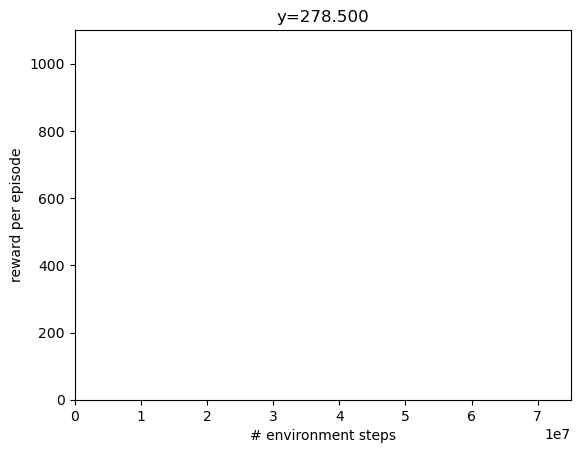

In [ ]:
from mujoco_playground import wrapper

make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(42)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:00<00:00, 1081.39it/s]



This browser does not support the video tag.


#### Brax SAC

In [ ]:
x_data, y_data, y_dataerr = [], [], []
times = [datetime.now()]


def progress(num_steps, metrics):
  clear_output(wait=True)

  times.append(datetime.now())
  x_data.append(num_steps)
  y_data.append(metrics["eval/episode_reward"])
  y_dataerr.append(metrics["eval/episode_reward_std"])

  plt.xlim([0, sac_params["num_timesteps"] * 1.25])
  plt.ylim([0, 1100])
  plt.xlabel("# environment steps")
  plt.ylabel("reward per episode")
  plt.title(f"y={y_data[-1]:.3f}")
  plt.errorbar(x_data, y_data, yerr=y_dataerr, color="blue")

  display(plt.gcf())

sac_training_params = dict(sac_params)
network_factory = sac_networks.make_sac_networks
if "network_factory" in sac_params:
  del sac_training_params["network_factory"]
  network_factory = functools.partial(
      sac_networks.make_sac_networks,
      **sac_params.network_factory
  )

train_fn = functools.partial(
    sac.train, **dict(sac_training_params),
    network_factory=network_factory,
    progress_fn=progress
)

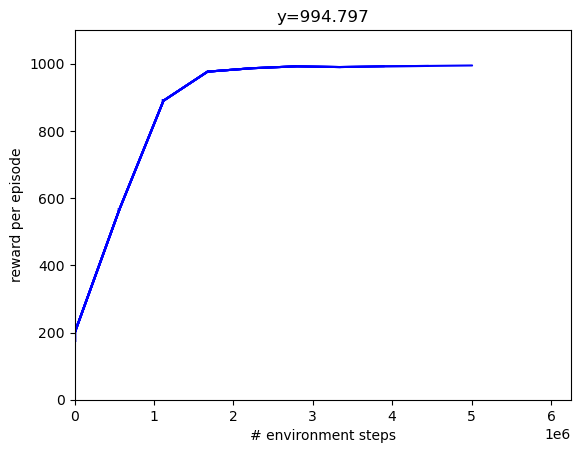

time to jit: 0:00:08.741344
time to train: 0:01:31.618712


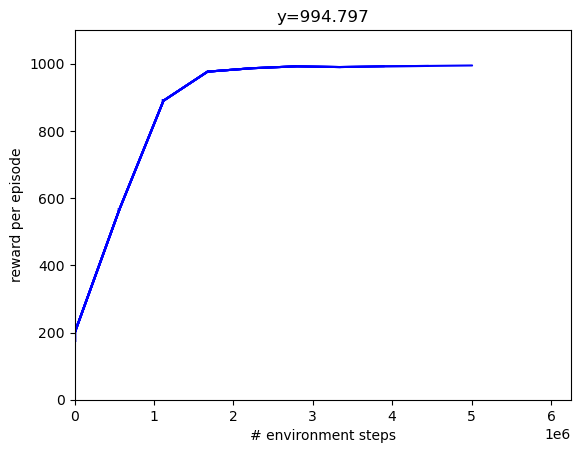

In [ ]:
make_inference_fn, params, metrics = train_fn(
    environment=env,
    wrap_env_fn=wrapper.wrap_for_brax_training,
)
print(f"time to jit: {times[1] - times[0]}")
print(f"time to train: {times[-1] - times[1]}")

In [ ]:
jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)
jit_inference_fn = jax.jit(make_inference_fn(params, deterministic=True))

In [ ]:
rng = jax.random.PRNGKey(0)
rollout = []
n_episodes = 1

for _ in range(n_episodes):
  state = jit_reset(rng)
  rollout.append(state)
  for i in range(env_cfg.episode_length):
    act_rng, rng = jax.random.split(rng)
    ctrl, _ = jit_inference_fn(state.obs, act_rng)
    state = jit_step(state, ctrl)
    rollout.append(state)

render_every = 1
frames = env.render(rollout[::render_every])
rewards = [s.reward for s in rollout]
media.show_video(frames, fps=1.0 / env.dt / render_every)

100%|██████████| 1001/1001 [00:00<00:00, 1225.20it/s]



This browser does not support the video tag.
